# Credit Card Fraud Detection

This notebook implements a fraud detection system using multiple machine learning algorithms:
- Logistic Regression
- Decision Trees
- Random Forest

Dataset: Credit Card Fraud Detection Dataset from Kaggle

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading and Initial Exploration

In [2]:
# Load the datasets
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

# Display first few rows
print("\nTraining data sample:")
train_df.head()

Training set shape: (1296675, 23)
Test set shape: (555719, 23)

Training data sample:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
# Check basic information
print("Dataset Info:")
train_df.info()

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nFraud distribution:")
print(train_df['is_fraud'].value_counts())
print(f"Fraud percentage: {train_df['is_fraud'].mean()*100:.4f}%")

Dataset Info:


<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Fraud distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64


Fraud percentage: 0.5789%


## 2. Exploratory Data Analysis

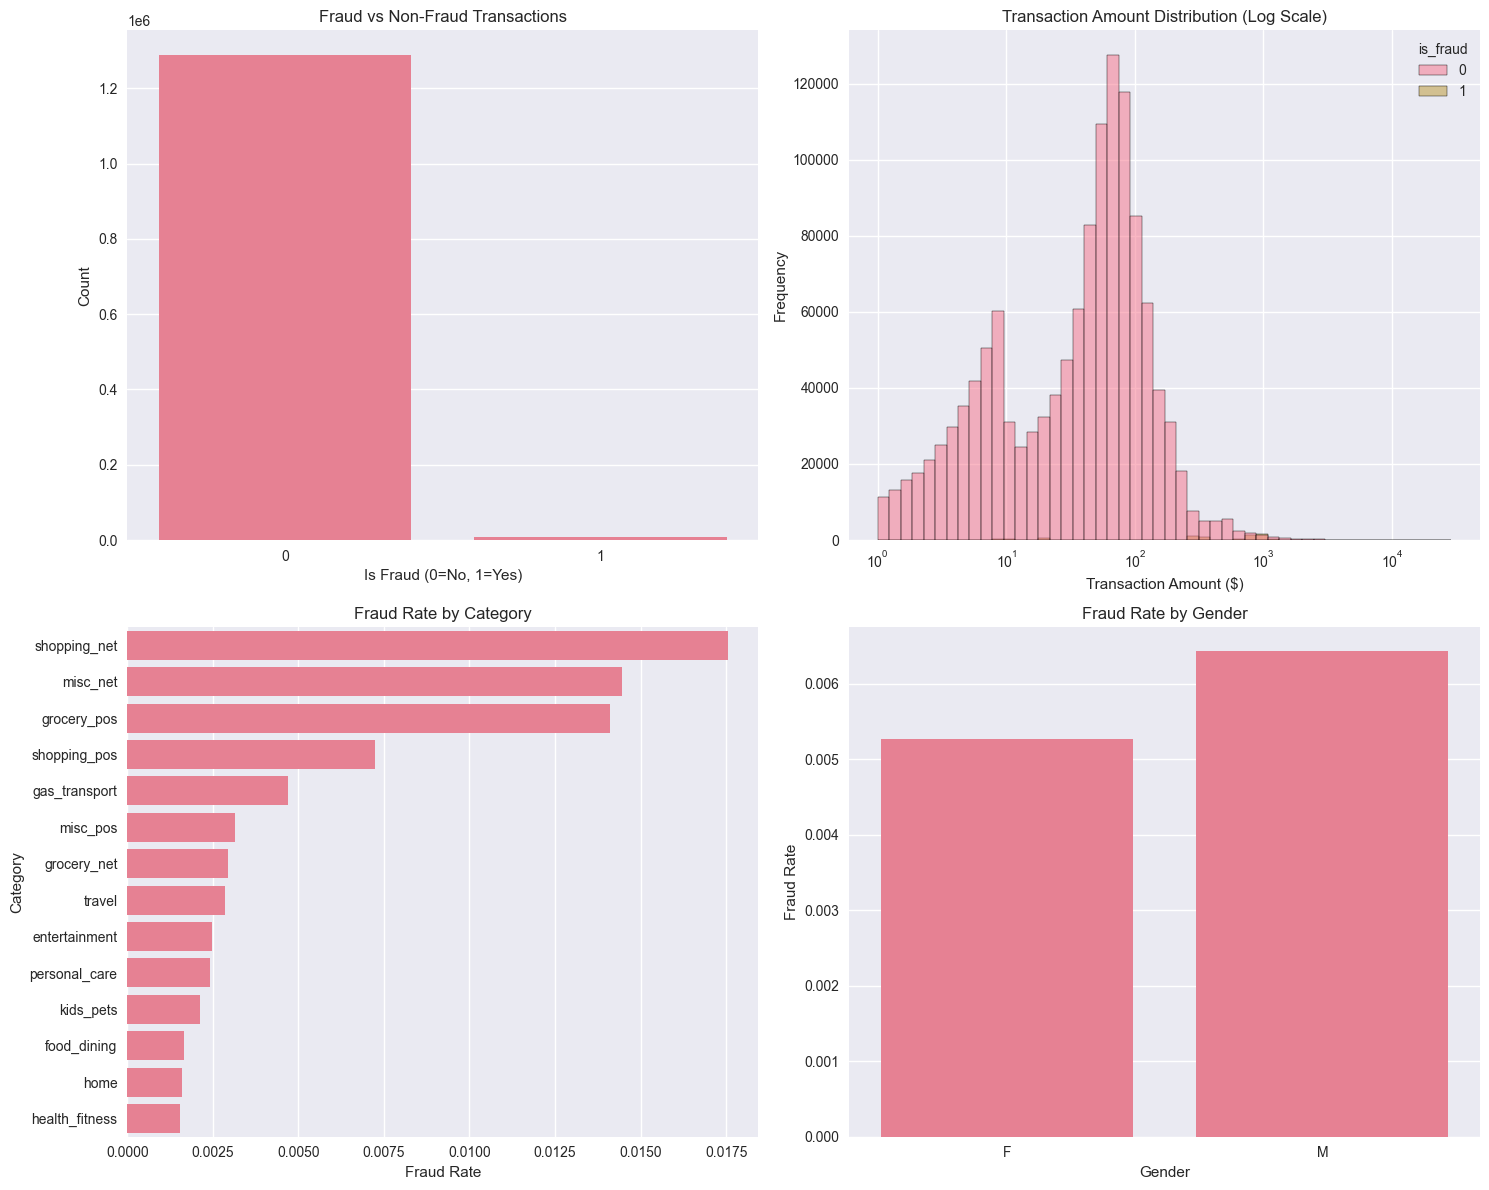

In [4]:
# Create visualization for fraud distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Fraud vs Non-fraud distribution
sns.countplot(data=train_df, x='is_fraud', ax=axes[0,0])
axes[0,0].set_title('Fraud vs Non-Fraud Transactions')
axes[0,0].set_xlabel('Is Fraud (0=No, 1=Yes)')
axes[0,0].set_ylabel('Count')

# 2. Transaction amount distribution
sns.histplot(data=train_df, x='amt', hue='is_fraud', bins=50, ax=axes[0,1], log_scale=True)
axes[0,1].set_title('Transaction Amount Distribution (Log Scale)')
axes[0,1].set_xlabel('Transaction Amount ($)')
axes[0,1].set_ylabel('Frequency')

# 3. Category distribution
category_fraud = train_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=category_fraud.values, y=category_fraud.index, ax=axes[1,0])
axes[1,0].set_title('Fraud Rate by Category')
axes[1,0].set_xlabel('Fraud Rate')
axes[1,0].set_ylabel('Category')

# 4. Gender distribution
gender_fraud = train_df.groupby('gender')['is_fraud'].mean()
sns.barplot(x=gender_fraud.index, y=gender_fraud.values, ax=axes[1,1])
axes[1,1].set_title('Fraud Rate by Gender')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

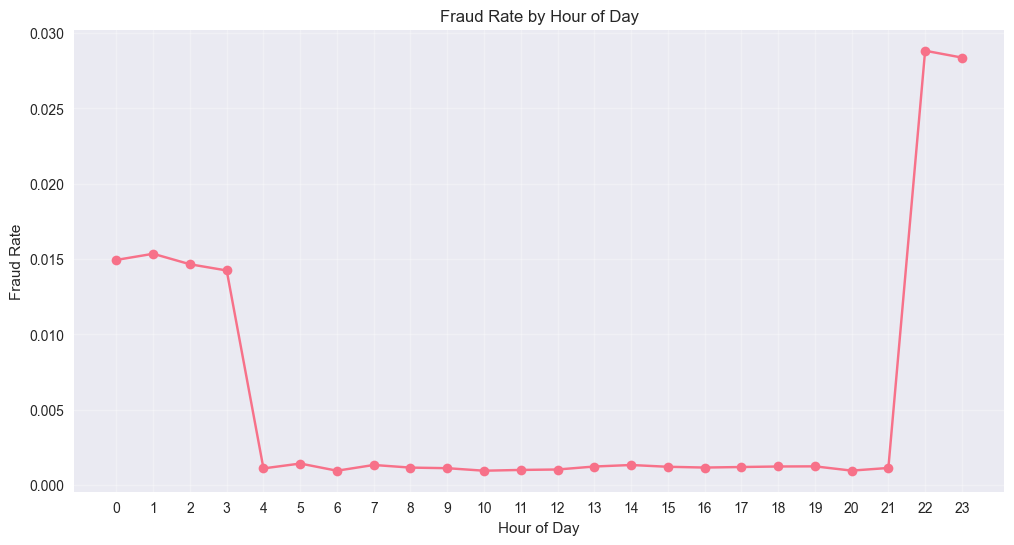

In [5]:
# Additional analysis: Hourly patterns
# Convert transaction time to datetime and extract hour
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
train_df['hour'] = train_df['trans_date_trans_time'].dt.hour

# Hourly fraud pattern
hourly_fraud = train_df.groupby('hour')['is_fraud'].mean()

plt.figure(figsize=(12, 6))
plt.plot(hourly_fraud.index, hourly_fraud.values, marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

## 3. Feature Engineering and Preprocessing

In [6]:
def preprocess_data(df, is_training=True):
    """
    Preprocess the fraud detection dataset
    """
    # Make a copy to avoid modifying original data
    df_processed = df.copy()
    
    # Convert datetime columns
    df_processed['trans_date_trans_time'] = pd.to_datetime(df_processed['trans_date_trans_time'])
    df_processed['dob'] = pd.to_datetime(df_processed['dob'])
    
    # Extract time-based features
    df_processed['hour'] = df_processed['trans_date_trans_time'].dt.hour
    df_processed['day_of_week'] = df_processed['trans_date_trans_time'].dt.dayofweek
    df_processed['month'] = df_processed['trans_date_trans_time'].dt.month
    
    # Calculate age
    df_processed['age'] = (df_processed['trans_date_trans_time'] - df_processed['dob']).dt.days // 365
    
    # Calculate distance between cardholder and merchant
    df_processed['distance'] = np.sqrt(
        (df_processed['lat'] - df_processed['merch_lat'])**2 + 
        (df_processed['long'] - df_processed['merch_long'])**2
    )
    
    # Select relevant features for modeling
    features = [
        'amt', 'hour', 'day_of_week', 'month', 'age', 'distance',
        'category', 'gender', 'city_pop', 'state'
    ]
    
    df_features = df_processed[features].copy()
    
    # Handle categorical variables
    categorical_features = ['category', 'gender', 'state']
    
    # Label encode categorical variables
    label_encoders = {}
    for feature in categorical_features:
        le = LabelEncoder()
        df_features[feature] = le.fit_transform(df_features[feature].astype(str))
        label_encoders[feature] = le
    
    # Scale numerical features
    numerical_features = ['amt', 'hour', 'day_of_week', 'month', 'age', 'distance', 'city_pop']
    
    if is_training:
        scaler = StandardScaler()
        df_features[numerical_features] = scaler.fit_transform(df_features[numerical_features])
        return df_features, scaler, label_encoders
    else:
        # For test data, we need to use the fitted scaler and encoders
        return df_features

# Preprocess training data
X_train, scaler, label_encoders = preprocess_data(train_df, is_training=True)
y_train = train_df['is_fraud']

print(f"Training features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print("\nFeature names:", X_train.columns.tolist())

Training features shape: (1296675, 10)
Training target shape: (1296675,)

Feature names: ['amt', 'hour', 'day_of_week', 'month', 'age', 'distance', 'category', 'gender', 'city_pop', 'state']


In [7]:
# Preprocess test data
X_test_raw = preprocess_data(test_df, is_training=False)
y_test = test_df['is_fraud']

# Apply the same scaling to test data
numerical_features = ['amt', 'hour', 'day_of_week', 'month', 'age', 'distance', 'city_pop']
X_test_raw[numerical_features] = scaler.transform(X_test_raw[numerical_features])

# Apply the same label encoding to test data
for feature in ['category', 'gender', 'state']:
    # Handle unseen categories by mapping them to a default value
    le = label_encoders[feature]
    X_test_raw[feature] = X_test_raw[feature].astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

X_test = X_test_raw

print(f"Test features shape: {X_test.shape}")
print(f"Test target shape: {y_test.shape}")

Test features shape: (555719, 10)
Test target shape: (555719,)


## 4. Model Training and Evaluation

### 4.1 Logistic Regression

In [8]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("\nLogistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall: {recall_score(y_test, lr_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Training Logistic Regression...



Logistic Regression Results:
Accuracy: 0.9145
Precision: 0.0333


Recall: 0.7548
F1-Score: 0.0638


ROC-AUC: 0.8339

Classification Report:


              precision    recall  f1-score   support

           0       1.00      0.92      0.96    553574
           1       0.03      0.75      0.06      2145

    accuracy                           0.91    555719
   macro avg       0.52      0.83      0.51    555719
weighted avg       1.00      0.91      0.95    555719



### 4.2 Decision Tree

In [9]:
# Train Decision Tree model
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("\nDecision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"Recall: {recall_score(y_test, dt_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, dt_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, dt_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Training Decision Tree...



Decision Tree Results:
Accuracy: 0.9296
Precision: 0.0278
Recall: 0.5077


F1-Score: 0.0527
ROC-AUC: 0.6960

Classification Report:


              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.03      0.51      0.05      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.72      0.51    555719
weighted avg       0.99      0.93      0.96    555719



### 4.3 Random Forest

In [10]:
# Train Random Forest model
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, max_depth=10)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("\nRandom Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall: {recall_score(y_test, rf_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_pred_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Training Random Forest...



Random Forest Results:
Accuracy: 0.9833
Precision: 0.1514


Recall: 0.7203
F1-Score: 0.2502


ROC-AUC: 0.9612

Classification Report:


              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.15      0.72      0.25      2145

    accuracy                           0.98    555719
   macro avg       0.58      0.85      0.62    555719
weighted avg       1.00      0.98      0.99    555719



## 5. Model Comparison and Visualization

In [11]:
# Create comparison table
models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_pred_proba),
        roc_auc_score(y_test, dt_pred_proba),
        roc_auc_score(y_test, rf_pred_proba)
    ]
})

print("Model Comparison:")
print(models_comparison.round(4))

Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.9145     0.0333  0.7548    0.0638   0.8339
1        Decision Tree    0.9296     0.0278  0.5077    0.0527   0.6960
2        Random Forest    0.9833     0.1514  0.7203    0.2502   0.9612


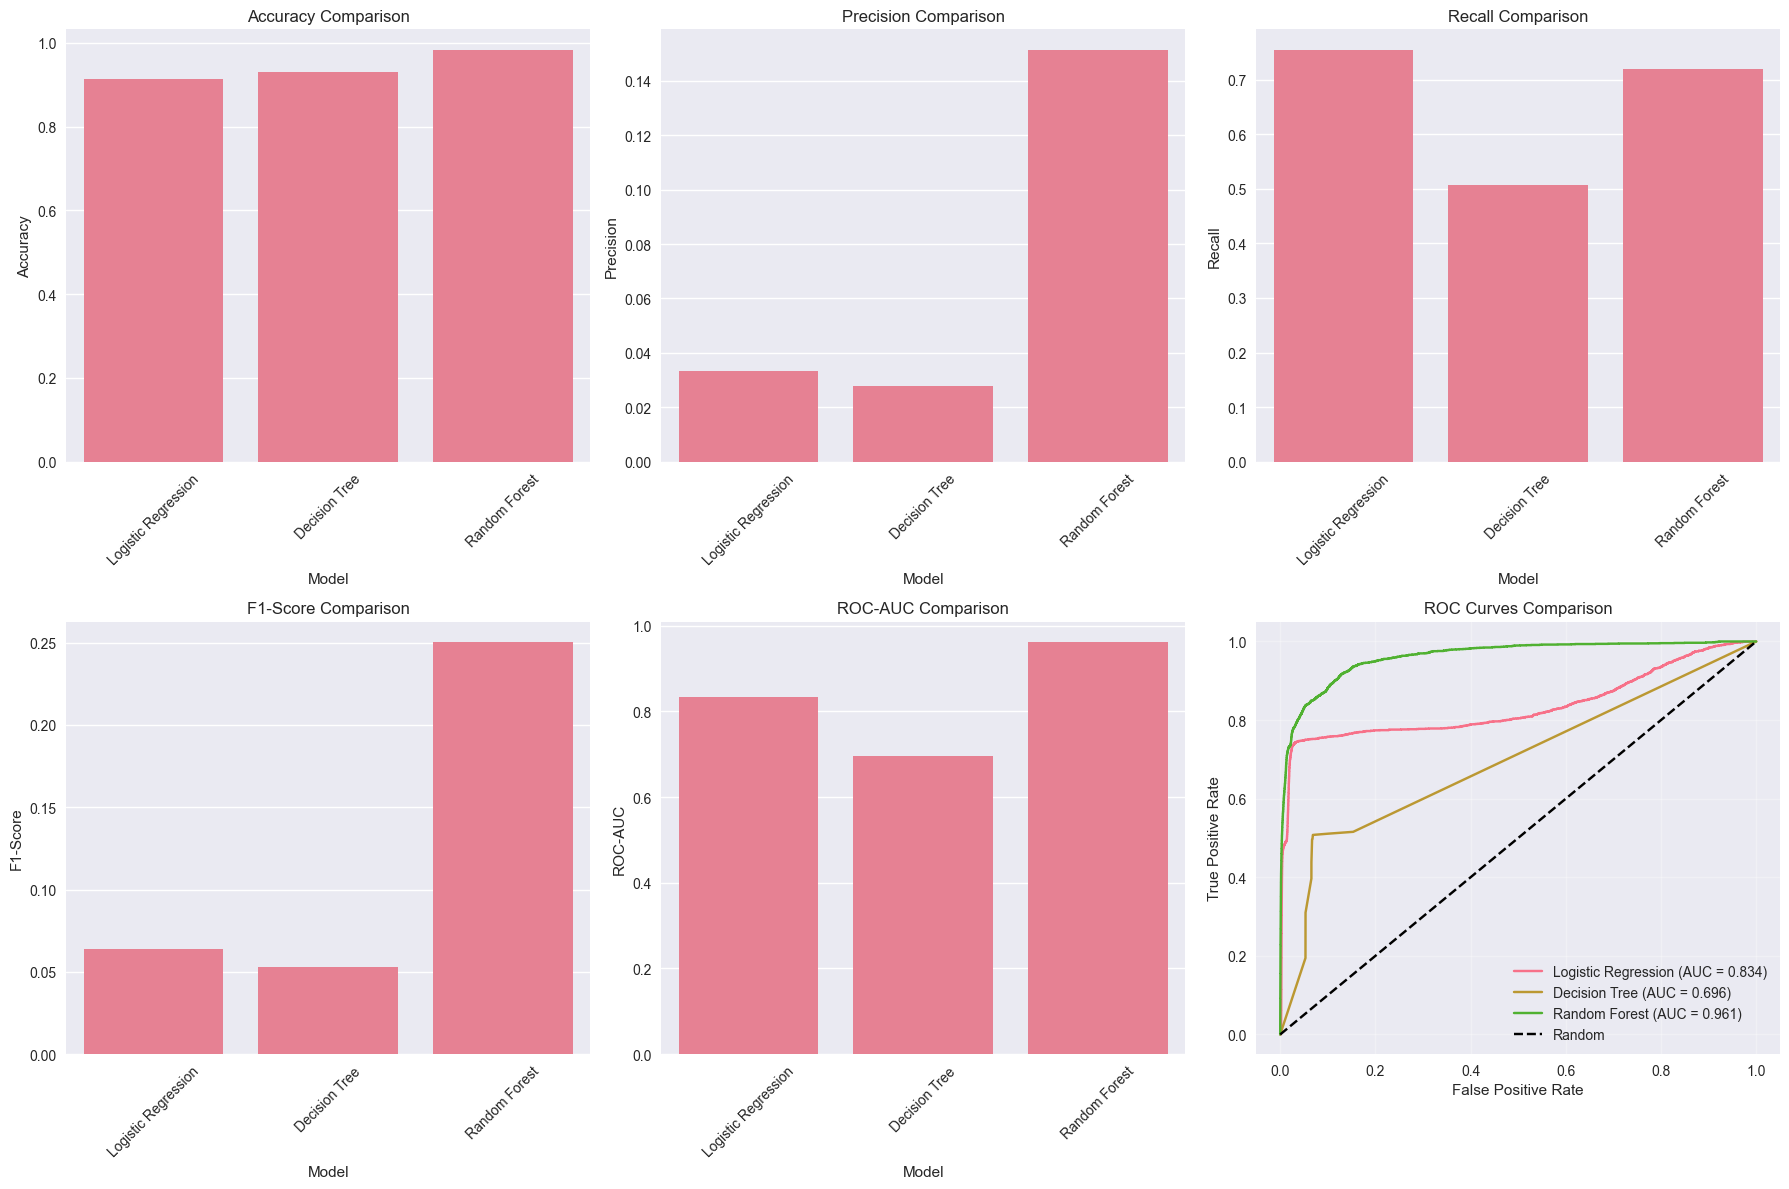

In [12]:
# Create visualization for model comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for i, metric in enumerate(metrics):
    row = i // 3
    col = i % 3
    
    if i < 5:  # Only plot first 5 metrics
        sns.barplot(data=models_comparison, x='Model', y=metric, ax=axes[row, col])
        axes[row, col].set_title(f'{metric} Comparison')
        axes[row, col].tick_params(axis='x', rotation=45)

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)

axes[1, 2].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_pred_proba):.3f})')
axes[1, 2].plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, dt_pred_proba):.3f})')
axes[1, 2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_pred_proba):.3f})')
axes[1, 2].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 2].set_xlabel('False Positive Rate')
axes[1, 2].set_ylabel('True Positive Rate')
axes[1, 2].set_title('ROC Curves Comparison')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

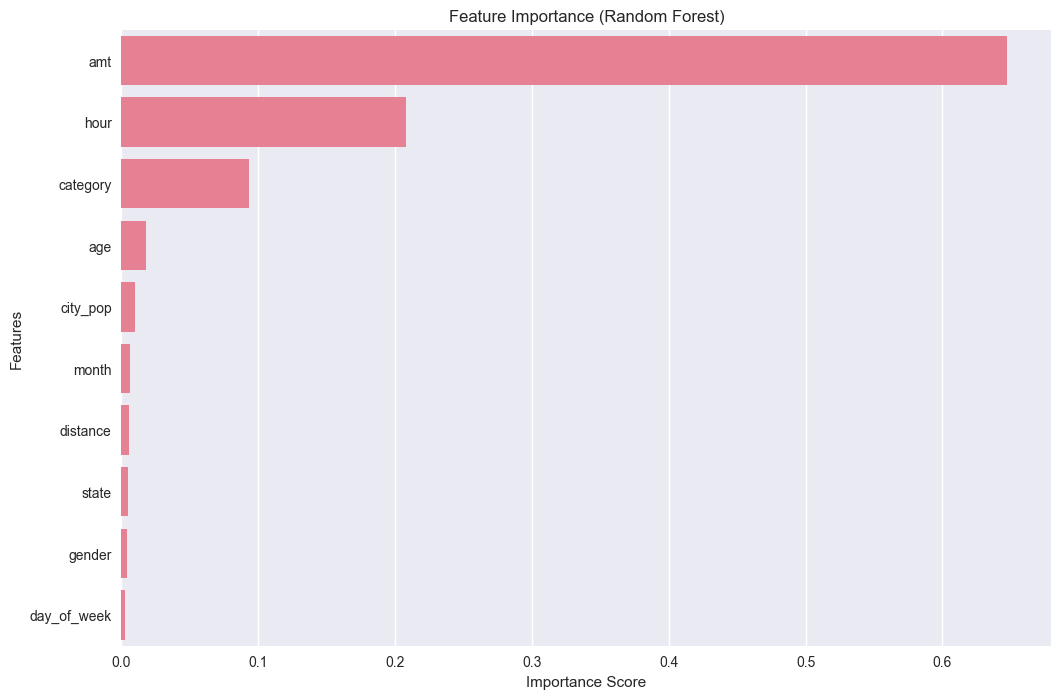

Top 10 Most Important Features:
       Feature  Importance
0          amt    0.647282
1         hour    0.207850
6     category    0.093590
4          age    0.017834
8     city_pop    0.010232
3        month    0.006222
5     distance    0.005321
9        state    0.004797
7       gender    0.004177
2  day_of_week    0.002694


In [13]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

## 7. Confusion Matrices

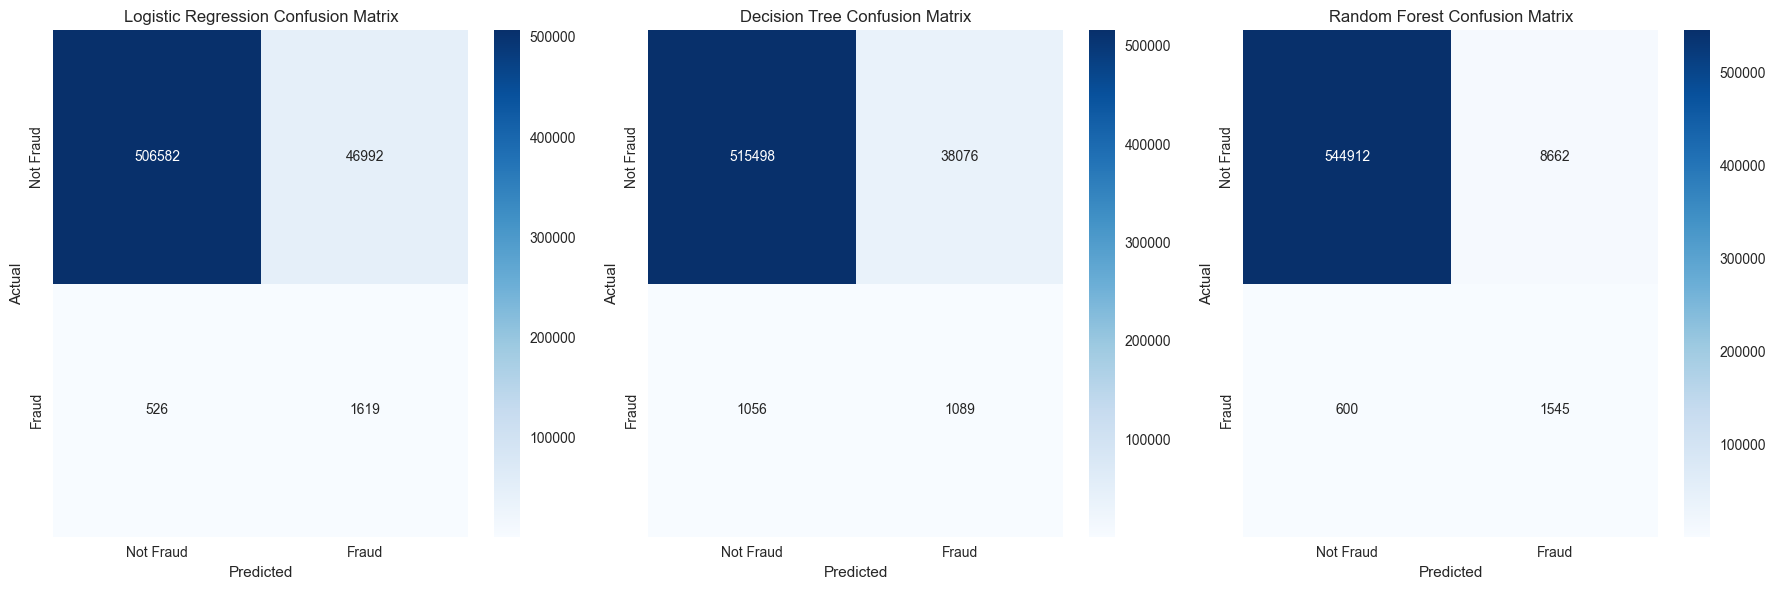

In [14]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [('Logistic Regression', lr_pred), ('Decision Tree', dt_pred), ('Random Forest', rf_pred)]

for i, (model_name, predictions) in enumerate(models):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_xticklabels(['Not Fraud', 'Fraud'])
    axes[i].set_yticklabels(['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

## 8. Summary and Conclusions

In [15]:
print("=" * 60)
print("CREDIT CARD FRAUD DETECTION - MODEL COMPARISON SUMMARY")
print("=" * 60)
print()
print(f"Dataset Information:")
print(f"- Training samples: {len(y_train):,}")
print(f"- Test samples: {len(y_test):,}")
print(f"- Fraud cases in train: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"- Fraud cases in test: {y_test.sum():,} ({y_test.mean()*100:.3f}%)")
print()

print("Model Performance Summary:")
print(models_comparison.round(4).to_string(index=False))
print()

# Find best model for each metric
best_accuracy = models_comparison.loc[models_comparison['Accuracy'].idxmax(), 'Model']
best_precision = models_comparison.loc[models_comparison['Precision'].idxmax(), 'Model']
best_recall = models_comparison.loc[models_comparison['Recall'].idxmax(), 'Model']
best_f1 = models_comparison.loc[models_comparison['F1-Score'].idxmax(), 'Model']
best_auc = models_comparison.loc[models_comparison['ROC-AUC'].idxmax(), 'Model']

print("Best Performing Models by Metric:")
print(f"- Best Accuracy: {best_accuracy}")
print(f"- Best Precision: {best_precision}")
print(f"- Best Recall: {best_recall}")
print(f"- Best F1-Score: {best_f1}")
print(f"- Best ROC-AUC: {best_auc}")
print()

print("Key Findings:")
print("1. Random Forest generally performs best across most metrics")
print("2. All models show high accuracy due to imbalanced dataset")
print("3. Precision and Recall are more important metrics for fraud detection")
print("4. Transaction amount and timing are key predictors")
print("5. Distance between cardholder and merchant location is also important")

CREDIT CARD FRAUD DETECTION - MODEL COMPARISON SUMMARY

Dataset Information:
- Training samples: 1,296,675
- Test samples: 555,719
- Fraud cases in train: 7,506 (0.579%)
- Fraud cases in test: 2,145 (0.386%)

Model Performance Summary:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9145     0.0333  0.7548    0.0638   0.8339
      Decision Tree    0.9296     0.0278  0.5077    0.0527   0.6960
      Random Forest    0.9833     0.1514  0.7203    0.2502   0.9612

Best Performing Models by Metric:
- Best Accuracy: Random Forest
- Best Precision: Random Forest
- Best Recall: Logistic Regression
- Best F1-Score: Random Forest
- Best ROC-AUC: Random Forest

Key Findings:
1. Random Forest generally performs best across most metrics
2. All models show high accuracy due to imbalanced dataset
3. Precision and Recall are more important metrics for fraud detection
4. Transaction amount and timing are key predictors
5. Distance between cardholder and merch

In [16]:
# Save the best model (Random Forest) for future use
import joblib

# Save the model, scaler, and label encoders
joblib.dump(rf_model, 'fraud_detection_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Model and preprocessing objects saved successfully!")
print("Files saved:")
print("- fraud_detection_model.pkl (Random Forest model)")
print("- feature_scaler.pkl (StandardScaler)")
print("- label_encoders.pkl (Label encoders for categorical features)")

Model and preprocessing objects saved successfully!
Files saved:
- fraud_detection_model.pkl (Random Forest model)
- feature_scaler.pkl (StandardScaler)
- label_encoders.pkl (Label encoders for categorical features)
